[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b — Bayesian Optimization with TuRBO

## 1. Overview

This notebook runs **TuRBO**, the proposed method for multi-band antenna tilt coordination, and reads it against the
baselines of notebook 03a.

**Question.** Does a model-guided search find a better tilt configuration than random search for the same number of
ray-traced evaluations, and than the rule-based sweep at any budget?

**Goals.**

- Run TuRBO on the same simulator, scenario, objective and evaluation budget as random search.
- Show how the trust region spends that budget.
- Measure what the best configuration changes on every KPI, and where on the map, beside both baselines.

The problem formulation is described in notebook 01, the setup tables and the objective $J$ in notebook 03a
(sections 3 and 7); they are not repeated here.

**Outputs.** One run directory per seed under `outputs/optim/turbo/`, tables under `reports/tables/03b_turbo/`,
figures under `reports/figures/03b_turbo/`. **Requirements.** A CUDA GPU, and notebook 03a run first. The shell
equivalent of the run is `task bo`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt"), ("botorch", "botorch")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import CapacitySpec, max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.methods.turbo.search import TURBO, TrustRegion
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds, matched to 03a: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("turbo", "random", "rule")

## 2. Method

TuRBO (Eriksson et al., 2019, `optim/method=turbo`) keeps one trust region, a box around the best point found so far,
and searches only inside it:

1. Evaluate the current configuration, then an initial Sobol design of `n_init` points. It is the same design random
   search starts with, so the two differ only in where they look afterwards.
2. Fit a Gaussian process to the objective $J$ of every evaluation since the last restart, in the unit cube the tilt
   box is rescaled to.
3. Centre the trust region on the best point, with side lengths stretched along the dimensions the GP finds smooth.
4. Draw candidates inside the region, perturbing a random subset of dimensions, and pick a batch of `batch_size` by
   Thompson sampling from the GP posterior.
5. Ray-trace the batch. After `success_tolerance` improving rounds the region doubles; after the failure tolerance of
   non-improving rounds it halves.
6. When the region shrinks below `length_min`, restart: a fresh Sobol design and a GP that forgets the collapsed
   region. Restarts spend the same budget.

Every candidate is ray-traced and scored exactly as in 03a; the GP only chooses where to look, and no reported number
comes from it.

## 3. Configuration

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)

turbo_cfg = load_config(overrides=["optim/method=turbo", *CONFIG_OVERRIDES])
budget = turbo_cfg.optim.method.budget
region = TrustRegion.from_config(turbo_cfg, space.n_dim, int(budget.batch_size))
settings = pd.DataFrame(
    {
        "Parameter": [
            "Optimized variables",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Batch size",
            "Trust region length: initial, minimum, maximum",
            "Success tolerance (rounds)",
            "Failure tolerance (rounds)",
            "Search seeds",
            "Solutions published",
        ],
        "Value": [
            space.n_dim,
            int(budget.n_init) + int(budget.n_iter),
            f"n_init={budget.n_init}, n_iter={budget.n_iter}",
            region.batch_size,
            f"{region.length_init:g}, {region.length_min:g}, {region.length_max:g}",
            region.success_tolerance,
            region.failure_tolerance,
            ", ".join(map(str, SEEDS)),
            int(turbo_cfg.optim.n_solutions),
        ],
    }
)
save_table(settings, "turbo_configuration")
settings

,Parameter,Value
0,Optimized variables,36
1,Evaluations (excluding the incumbent),144
2,Budget split,"n_init=16, n_iter=128"
3,Batch size,3
4,"Trust region length: initial, minimum, maximum","0.8, 0.0078125, 1.6"
5,Success tolerance (rounds),3
6,Failure tolerance (rounds),12
7,Search seeds,42
8,Solutions published,4


## 4. Runs

A TuRBO run already on disk for the same seed and the current scenario is reused; delete its directory under
`outputs/optim/turbo/` to repeat it. Runs from an earlier scenario are ignored. The baseline runs are read from disk,
not repeated, and every run is checked comparable with the current radio map.

In [4]:
scenario = str(baseline["scenario_id"])


def on_disk():
    # The newest finished run of each method and seed on the current scenario.
    current = [r for r in run_store.discover(cfg.optim.output.dir) if r.scenario_id == scenario]
    return run_store.latest_per_method_and_seed(current)


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("turbo", seed) not in done:
        run(load_config(overrides=["optim/method=turbo", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

runs = [
    r
    for r in on_disk()
    if r.method == "rule" or (r.method in ("turbo", "random") and r.seed in SEEDS)
]
missing = [m for m in METHODS if not any(r.method == m for r in runs)]
if missing:
    raise run_store.RunError(
        f"No {', '.join(missing)} run on scenario {scenario}; run notebook 03a first."
    )
checks = run_store.verify(runs, baseline, cfg)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
best = compare.best_run_per_method(runs)
turbo = best["turbo"]

jitc_llvm_init(): LLVM API initialization failed ..



turbo: 4 solutions published

 solution  recommended  hole_rate  overlap_rate  overlap_neighbor_mean  weak_rate  rsrp_p05_dbm  rsrp_p50_dbm  sinr_p05_db  sinr_p50_db  served_rate  load_imbalance  objective
        0        False     0.1125        0.3164                 0.9625     0.3069     -108.5644      -84.1068      -5.8729       8.4932       0.5265          0.9098     0.6651
        1         True     0.1079        0.3070                 0.9918     0.2665     -107.4394      -81.7281      -4.9822      11.0255       0.5898          0.9746     0.7049
        2        False     0.1082        0.3085                 0.9642     0.2676     -107.5098      -81.7279      -5.0510      11.0752       0.5907          0.9727     0.7049
        3        False     0.1077        0.3113                 1.0060     0.2665     -107.4142      -81.7076      -4.9590      10.7437       0.5924          0.9599     0.7047

wrote outputs\optim\turbo\2026-09-22_08-27-54
  history: outputs\optim\turbo\2026-09-22_

3 runs; 24 of 24 comparability checks hold


## 5. Search Progress

Best objective found so far per evaluation, from the search history, for TuRBO and both baselines. With several seeds
the line is the mean and the band spans the best and worst seed.

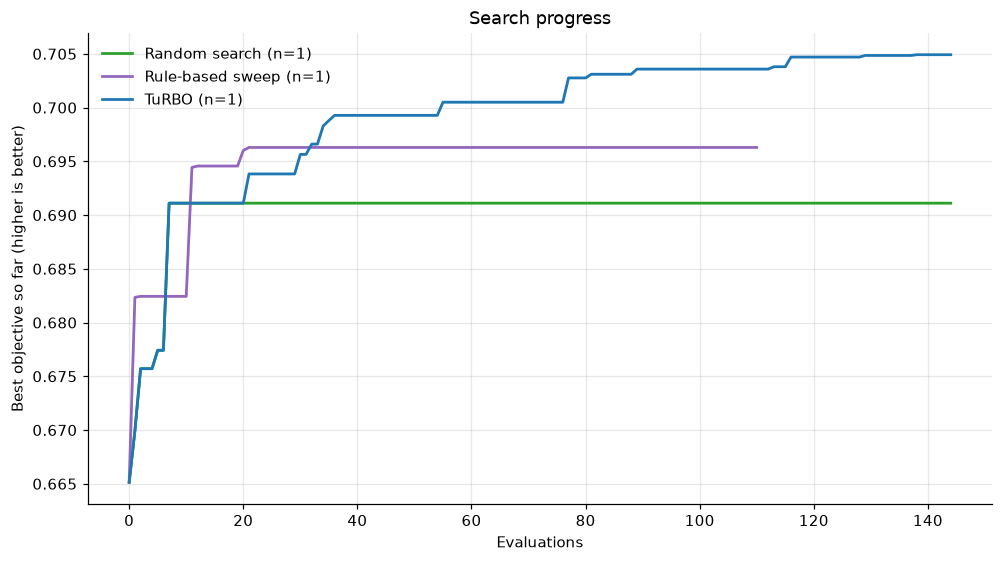

In [5]:
figure = plots.convergence_plot(compare.convergence(runs))
save_fig(figure, "search_progress")
plt.show()

### Where TuRBO spent its budget

Every evaluation of TuRBO's best run, marked by what proposed it. A Sobol block after the initial design is a restart.

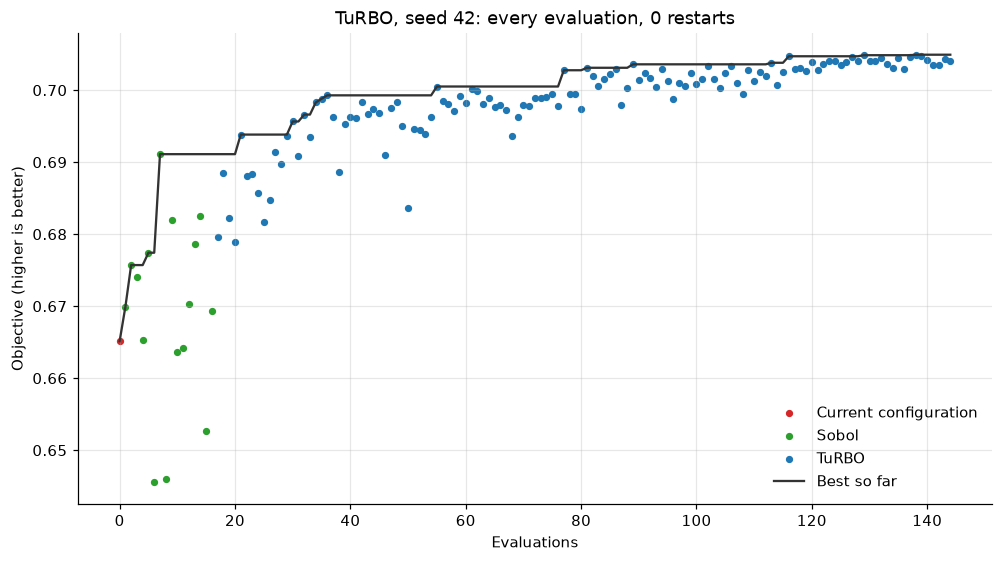

,Evaluations,Mean objective,Best objective
Proposed by,,,
Current configuration,1,0.6651,0.6651
Sobol,16,0.6693,0.6911
TuRBO,128,0.6987,0.7049


In [6]:
history = turbo.history
proposer = history["generation_node"].replace({"attached": "Current configuration"})
colours = {
    "Current configuration": plots.COLOURS["incumbent"],
    "Sobol": plots.COLOURS["random"],
    TURBO: plots.COLOURS["turbo"],
}
from_model = (history["generation_node"] == TURBO).to_numpy()
# A restart is a Sobol row directly after a trust-region proposal.
restarts = int((~from_model[1:] & from_model[:-1]).sum())

figure, axis = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
for name, group in history.groupby(proposer, sort=False):
    axis.scatter(group["iteration"], group["objective"], s=14, color=colours[name], label=name)
axis.plot(history["iteration"], history["objective"].cummax(), color="0.2", lw=1.5, label="Best so far")
axis.set_xlabel("Evaluations")
axis.set_ylabel("Objective (higher is better)")
axis.set_title(f"TuRBO, seed {turbo.seed}: every evaluation, {restarts} restarts")
axis.legend()
save_fig(figure, "turbo_evaluations")
plt.show()

by_proposer = history.groupby(proposer, sort=False)["objective"].agg(["size", "mean", "max"])
by_proposer = by_proposer.rename(
    columns={"size": "Evaluations", "mean": "Mean objective", "max": "Best objective"}
).rename_axis("Proposed by")
save_table(by_proposer.reset_index(), "turbo_evaluations_by_proposer")
by_proposer

**Observations.** Random search stops improving at evaluation 7 of 145, inside the Sobol design it shares with
TuRBO. The rule-based sweep gets all of its gain from its first pass (its best is evaluation 21). TuRBO starts from
that same design and keeps improving through the budget. Because the first 16 points are shared, TuRBO *ties* random
search's best at evaluation 7 rather than beating it there, and it passes the rule sweep's best at evaluation 32.

The model is steering rather than scattering: the trust-region proposals score higher on average than the design
points, 0.6987 against 0.6693 over 128 and 16 evaluations. Only 16 Sobol points appear in the whole history, so the
region never collapsed and no restart was spent. The best configuration is evaluation 138 of 144, so the search was
still improving late.

## 6. Best Tilt Configuration

The deliverable of TuRBO's best run: current and proposed tilt per cell-band. Negative change is uptilt.

TuRBO: run 2026-09-22_08-27-54, seed 42, best evaluation 138


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,6.4435,9.8527,-6.3713
1,2600 MHz,12,12,7.7016,11.8457,-7.7016
2,700 MHz,12,12,5.3517,7.2315,-2.7935


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,2.2513,-9.7487,0.0,15.0
1,n0c0,1800 MHz,10.0,0.1473,-9.8527,0.0,15.0
2,n0c0,700 MHz,8.0,1.4286,-6.5714,0.0,15.0
3,n0c1,2600 MHz,12.0,4.9049,-7.0951,0.0,15.0
4,n0c1,1800 MHz,10.0,0.2987,-9.7013,0.0,15.0
5,n0c1,700 MHz,8.0,1.9416,-6.0584,0.0,15.0
6,n0c2,2600 MHz,12.0,6.5716,-5.4284,0.0,15.0
7,n0c2,1800 MHz,10.0,5.8291,-4.1709,0.0,15.0
8,n0c2,700 MHz,8.0,14.2853,6.2853,0.0,15.0
9,n1c0,2600 MHz,12.0,4.8892,-7.1108,0.0,15.0


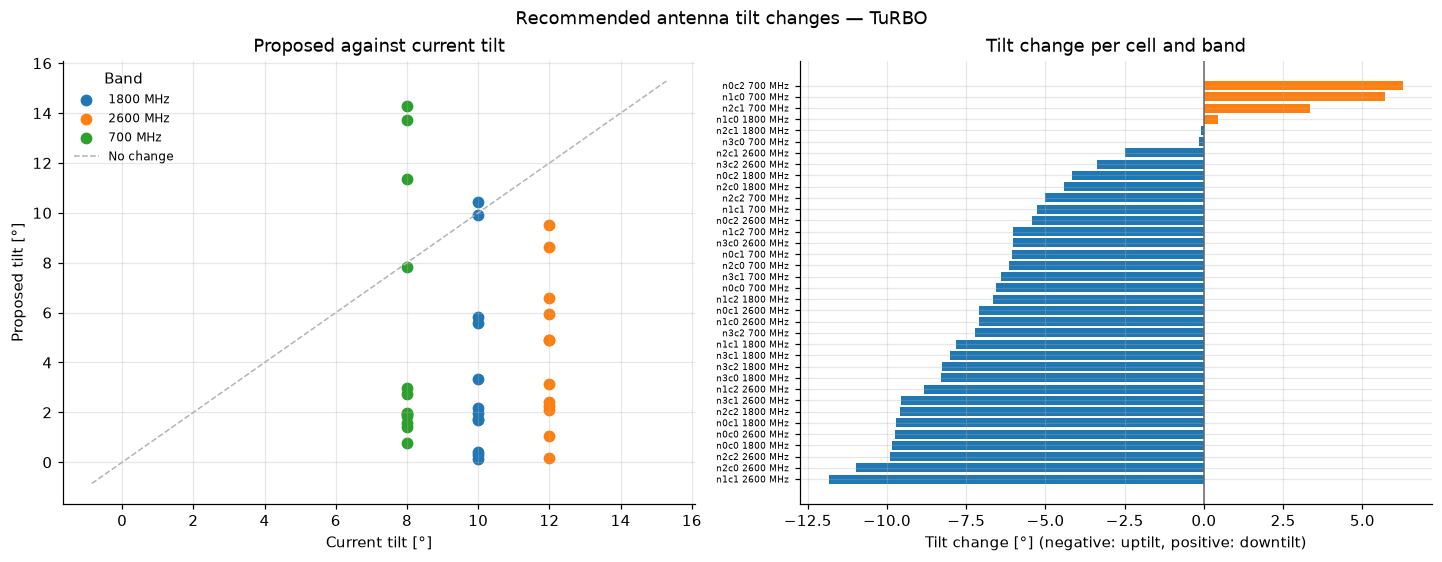

In [7]:
tilt = readable(turbo.best_tilt)
save_table(tilt, "best_tilt_turbo")
summary = readable(compare.tilt_movement(turbo))
save_table(summary, "tilt_movement_turbo")
print(
    f"{label('turbo')}: run {turbo.run_id}, seed {turbo.seed}, best evaluation {turbo.best_index}"
)
display(summary)
display(tilt)
figure = plots.tilt_movement_plot(turbo.best_tilt, "turbo")
save_fig(figure, "tilt_movement_turbo")
plt.show()

**Observations.** Unlike the rule sweep, which moves a whole band at once, TuRBO chooses per cell-band: 32 of the
36 are uptilted and 4 downtilted. **None of the downtilts is on 2600 MHz.** Three are on 700 MHz (n0c2, n1c0 and
n2c1, by 3.4° to 6.3°) and one is on 1800 MHz (n1c0, by 0.4°). Proposed tilts span 0.15° to 14.29°, so the search
presses against the bottom of the 0-15° box.

The per-band means show the strategy.
- **2600 MHz** is uptilted on all twelve cells, by 7.70° on average, which widens every high-band footprint.
- **1800 MHz** is uptilted by 6.37° on average, on eleven of the twelve cells.
- **700 MHz** averages only 2.79° of uptilt, because three of its carriers are pulled in by 3° to 6° where the
  sector's upper layers widen.

That is consistent with 700 MHz showing TuRBO's largest per-band overlap cut (section 9), and it is a move a
three-dimensional per-band sweep cannot express: the sweep sets every cell on every band to 1.67°. With a single seed,
it is not established which of these per-cell differences matter and which are where the trust region happened to be
when the budget ended.

## 7. Final Results

### KPI comparison

TuRBO's best configuration against the current one, on every UE. Relative improvement is signed so that positive is
better whichever direction the KPI runs, as in 03a:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

Then every method side by side: what its best run found on every UE, and what it cost.

In [8]:
table = compare.delta_table(turbo.incumbent_kpi, turbo.best_kpi)
sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
table = readable(table).rename(
    columns={
        "direction": "Direction",
        "before": "Initial",
        "after": label("turbo"),
        "delta": "Change",
        "verdict": "Verdict",
        "improvement_pct": "Improvement [%]",
    }
)
save_table(table, "kpi_comparison_turbo")
display(table)

results = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(results, "method_results")
results

,KPI,Direction,Initial,TuRBO,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1079,-0.0046,better,4.0464
1,Co-band overlap rate,minimise,0.3164,0.3070,-0.0094,better,2.9679
2,Overlap neighbours per covered tile,minimise,0.9625,0.9918,0.0292,worse,-3.0357
3,Weak coverage rate,minimise,0.3069,0.2665,-0.0404,better,13.1670
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.4394,1.1250,better,1.0362
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-81.7281,2.3788,better,2.8283
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-4.9822,0.8906,better,15.1653
7,"Median SINR, p50 [dB]",maximise,8.4932,11.0255,2.5322,better,29.8148
8,Served UE rate,maximise,0.5265,0.5898,0.0632,better,12.0128
9,Cell load imbalance (CoV),minimise,0.9098,0.9746,0.0648,worse,-7.1193


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,6.6332,10.3287,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,1.0092,0.6911,8,3
1,Rule-based sweep,42,111,21,4.5005,7.2360,0.1044,0.3181,1.1866,0.2535,-106.9675,-80.7966,-4.9663,9.9010,0.5988,0.9963,0.6963,8,3
2,TuRBO,42,145,138,9.0447,17.1768,0.1079,0.3070,0.9918,0.2665,-107.4394,-81.7281,-4.9822,11.0255,0.5898,0.9746,0.7049,9,2


**Observations.** TuRBO reaches the highest objective of the three methods: 0.7049, against 0.6963 for the sweep
and 0.6911 for random search, from an incumbent of 0.6651. $J$ scores each band for one dominant cell at usable
strength and takes the contraharmonic mean over the tile's bands (ADR 0003). It is bounded in $[0, 1]$, and these
values are not comparable with any figure scored under an earlier objective. TuRBO improves 9 of the 11 reported
measures.

**What TuRBO wins is crowding.**
- It is the only method that lowers the band-collapsed co-band overlap rate (0.3164 to 0.3070).
- It lowers overlap on all three bands, with the largest 2600 MHz cut of any method (0.2010 to 0.1899).
- It cuts the share of covered tiles carrying three or more neighbours from 17.6 % to 16.0 %, the best of the three.
- Effective coverage, the share of tiles scoring above 0.75, rises from 52.3 % to 59.5 %, the best of the three.

**It worsens two measures:** overlap neighbours per covered tile (+3.0 %) and cell load imbalance (+7.1 %), which the
objective does not read.

**The sweep still wins more of the KPI table.** TuRBO gains +5.98 % on $J$ against the sweep's +4.68 %, on 145
evaluations against 111. But the sweep beats TuRBO on 6 of the 10 KPIs: hole rate, weak rate, both RSRP percentiles,
cell-edge SINR and the served rate. TuRBO takes the other four: overlap rate, overlap neighbours, median SINR and load
imbalance. TuRBO found its best at evaluation 138 of 145 and was still improving. It spent the longest wall clock of
the three (17.2 minutes), because each round also fits a GP.

## 8. Coverage Map Comparison

Best-server RSRP before and after TuRBO, and the tiles that crossed the coverage-hole threshold; then the RSRP change
of each method's best configuration on one scale. Crimson triangles are the masts.

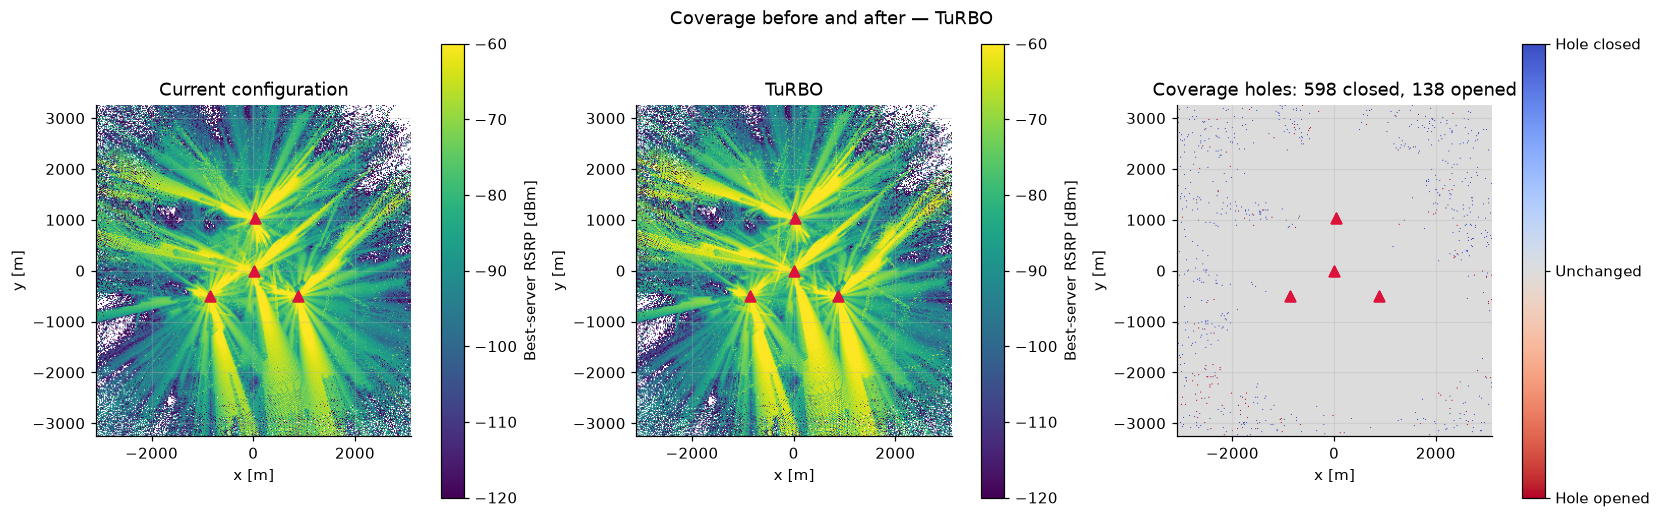

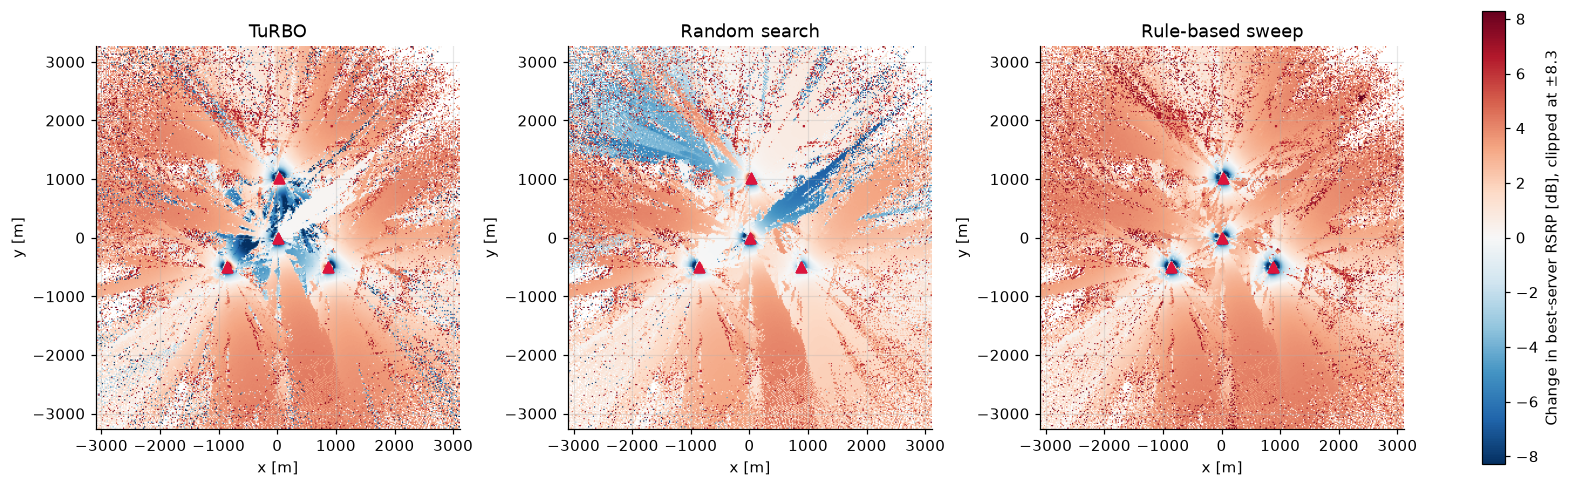

In [9]:
best_rsrp = {"incumbent": max_rsrp(baseline["rsrp_dbm"].astype(float))}
best_rsrp.update({m: max_rsrp(best[m].radio_map["rsrp_dbm"].astype(float)) for m in METHODS})

figure = plots.coverage_maps(
    best_rsrp["incumbent"], best_rsrp["turbo"], baseline, cfg, cells=cells, name="turbo"
)
save_fig(figure, "coverage_before_after_turbo")
plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

**Observations.** TuRBO raises best-server RSRP on 88.2 % of tiles, by a median of 2.8 dB, and closes 598 hole
tiles while opening 138. The rule sweep is the larger change on this view: 96.9 % of tiles improve, by a median of
3.3 dB, with 818 holes closed and 3 opened, because it uptilts every cell on a band together and so lifts the whole
scene. Random search is the weakest of the three: 80.6 % of tiles improve, median +1.5 dB, and it opens 103 holes
against 531 closed.

Signal strength does score, through the strength factor, and the sweep's stronger signal is worth more $J$ than
TuRBO's. What TuRBO gets back is contention. The sweep's uniform uptilts crowd every layer and give up about 0.016 of
$J$ to crowding, while TuRBO's per-cell tilts do not (ADR 0003, Measured outcome). That difference is larger than
TuRBO's whole margin.

## 9. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs, for the current configuration and
each method's best. Demand is the incumbent's for every configuration, so the weights do not move. Mean overlapping
neighbours is the diagnostic defined in 03a section 6; no score reads it.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,TuRBO: Share of area,TuRBO: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1125,0.000,0.1079,0.0044,0.1083,0.0027,0.1044,0.0000
1,weak,0.3069,0.836,0.2665,0.7874,0.2864,0.7967,0.2535,0.7673
2,good,0.5806,0.164,0.6256,0.2082,0.6054,0.2006,0.6420,0.2327


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3164,0.9625
1,TuRBO,0.3070,0.9918
2,Random search,0.3254,1.0303
3,Rule-based sweep,0.3181,1.1866


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,TuRBO,10087.0,0.4102,0.2414,7.4675,40.8734,0.4457,0.0712,0.0729
2,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
3,Rule-based sweep,10087.0,0.4012,0.3564,7.8600,39.2656,0.4629,0.0638,0.0721


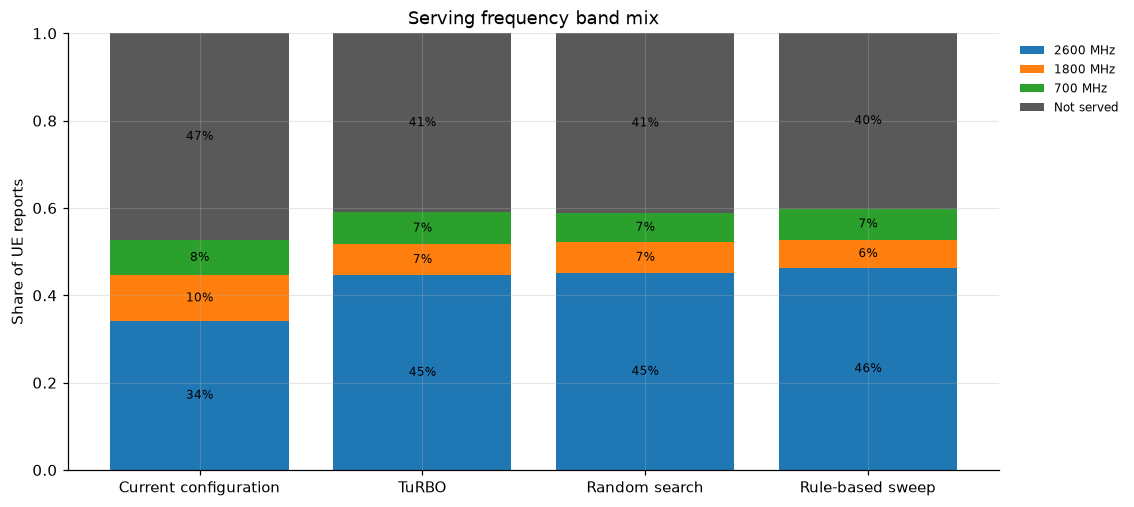

,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,prb_utilisation_max,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,TuRBO,All bands,0.1079,0.3070,0.9918,0.2665,-107.4394,-81.7281,-4.9822,11.0255,0.5898,0.8000,0.9746
5,TuRBO,2600 MHz,0.2546,0.1899,0.3852,0.3905,-113.4348,-90.9086,-15.6287,3.3315,0.4457,0.8000,0.5635
6,TuRBO,1800 MHz,0.2209,0.1976,0.3686,0.3313,-111.1323,-87.1847,-10.3754,6.7230,0.0712,0.7964,0.8830
7,TuRBO,700 MHz,0.1372,0.2171,0.3598,0.2650,-107.6290,-82.1059,-4.6391,10.4426,0.0729,0.7989,1.0870
8,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
9,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835


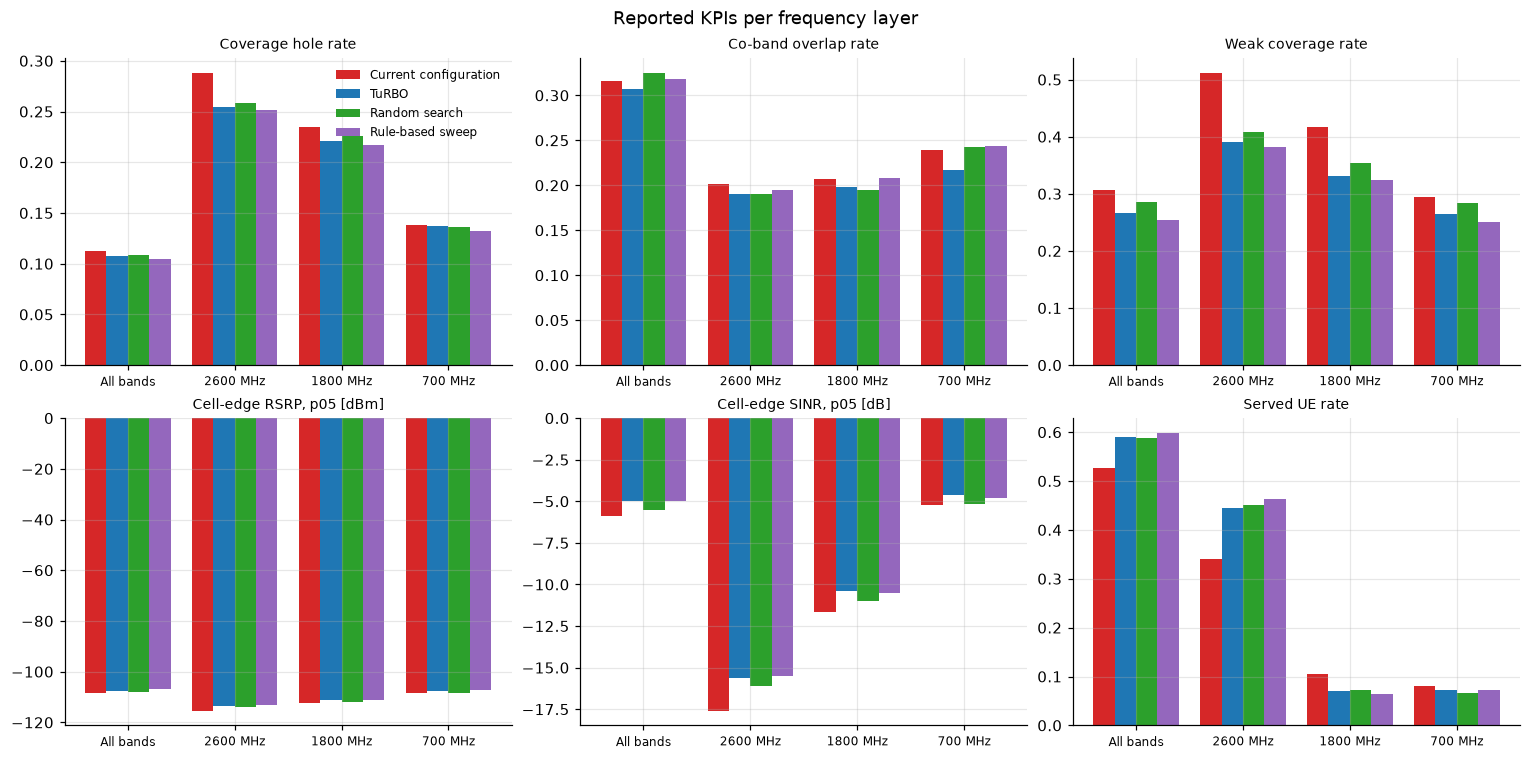

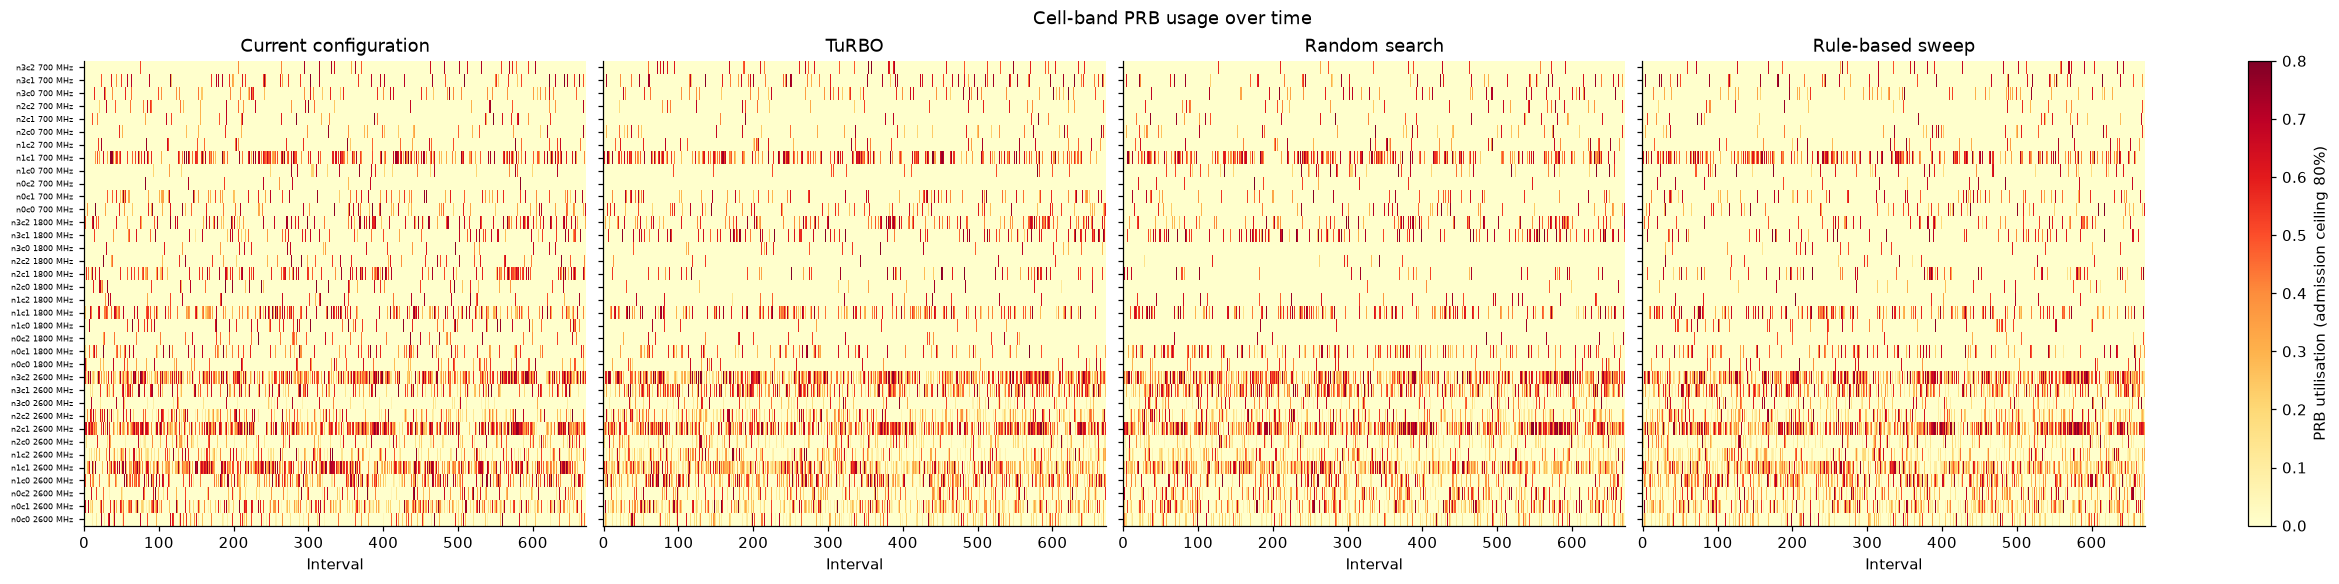

peak utilisation over every cell-band and interval: 80.0% (admission ceiling 80%)


In [10]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [turbo.incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [
            mean_overlap_neighbors(c.rsrp) for c in configurations.values()
        ],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print(
    "Band preference, most preferred first:",
    ", ".join(label(b) for b in cfg.kpi.capacity.band_preference),
)
service = {
    name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()
}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

tx_names = [str(name) for name in baseline["tx_name"]]
max_prb = CapacitySpec.from_config(cfg, band_labels, len(tx_names)).max_prb

# Every reported KPI, over all bands and per band, through the same functions:
# a band row is the definition given one band's layers, nothing new.
per_band = compare.band_kpis(configurations, band_labels, cfg)
save_table(readable(per_band), "band_kpis")
display(readable(per_band))
figure = plots.band_kpi_panels(
    per_band,
    ("hole_rate", "overlap_rate", "weak_rate", "rsrp_p05_dbm", "sinr_p05_db", "served_rate"),
)
save_fig(figure, "band_kpis")
plt.show()

# The series prb_utilisation_max and load_imbalance reduce. The admission
# ceiling bounds every cell in it, so a band running at the ceiling is a cell
# that refused traffic, not one that overloaded.
ceiling = float(cfg.kpi.capacity.max_admission_utilisation)
usage = compare.prb_usage_by_time(configurations, band_labels, tx_names, max_prb)
save_table(readable(usage), "prb_usage_by_time")
figure = plots.prb_usage_heatmaps(usage, ceiling)
save_fig(figure, "prb_usage")
plt.show()
print(f"peak utilisation over every cell-band and interval: {usage['utilisation'].max():.1%} "
      f"(admission ceiling {ceiling:.0%})")


### Coverage holes

The current configuration puts no demand at all on hole tiles. All three methods cut the hole rate by area: 0.1125
falls to 0.1079 for TuRBO, 0.1044 for the sweep and 0.1083 for random search. In exchange, TuRBO moves 0.44 % of
demand onto holes and random search 0.27 %; the sweep moves none. Nothing in $J$ is weighted by demand, so a hole
where nobody stands costs the same as a hole in a hotspot.

### Coverage overlap

**Only TuRBO improves the band-collapsed overlap rate:** 0.3164 falls to 0.3070 under TuRBO and rises to 0.3181
under the sweep and 0.3254 under random search. All three raise the mean neighbour count over covered tiles, to
0.992, 1.187 and 1.030. Every method closes hundreds of hole tiles, and a newly covered tile arrives with neighbours
of its own.

Per band, TuRBO improves every layer: 2600 MHz 0.2010 to 0.1899, 1800 MHz 0.2067 to 0.1976 and 700 MHz 0.2396 to
0.2171. The contraharmonic mean charges a tile for crowding on any of its covered layers, not only on its best one.
TuRBO also leaves the fewest tiles in a three-or-more pile-up: 16.0 % of covered tiles, against the incumbent's
17.6 %.

### Multi-band coordination

**All three methods push traffic onto the preferred 2600 MHz layer.** Its share of UE reports rises from 34.1 % to
44.6 % under TuRBO, 45.1 % under random search and 46.3 % under the sweep, and 1800 MHz falls from 10.5 % to between
6.4 % and 7.1 %. That follows from the tilts of section 6: every 2600 MHz carrier is uptilted, and the serving rule
prefers that layer wherever it clears the threshold.

Service quality rises under all three. Under TuRBO, median served SINR rises from 5.1 to 7.5 dB, the median PRBs per
served UE fall from 53.2 to 40.9, and the 10th-percentile served SINR rises from -0.38 to +0.24 dB. The sweep is
slightly better on all three: 7.9 dB, 39.3 PRBs and +0.36 dB.

### Weak coverage

Weak coverage falls by area under every method: 30.7 % to 26.7 % for TuRBO, 25.4 % for the sweep and 28.6 % for
random search. The share of demand on weak tiles falls with it, from 83.6 % to 78.7 %, 76.7 % and 79.7 %.

## 10. Key Observations

- **TuRBO finds a mixed configuration, not a uniform uptilt.** 32 of the 36 cell-bands are uptilted and 4
  downtilted, none of them on 2600 MHz, and proposed tilts span 0.15° to 14.29°. The sweep, by contrast, sets every
  cell on every band to 1.67°.
- **The strategy is to widen the high band everywhere and pull in the low band selectively.** Every 2600 MHz carrier
  is uptilted, and three 700 MHz carriers are downtilted where their sectors' upper layers widen. TuRBO is the only
  method that lowers co-band overlap, on every band and on the band-collapsed rate.
- **The model earns its margin over random search.** At the same budget and seed it beats random search on the
  objective (0.7049 against 0.6911). TuRBO's own proposals averaged 0.6987, against the shared Sobol design's 0.6693,
  and its *median* candidate (0.6990) beat random search's single best.
- **It beats the three-variable rule-based sweep on $J$** (0.7049 against 0.6963), passing the sweep's final answer
  at evaluation 32. But the sweep still beats it on 6 of the 10 KPIs, every coverage and service measure among them.
  TuRBO wins the crowding and quality measures.
- **The search was still improving at the end of its budget** (best at evaluation 138 of 145, no restart), so the
  result is limited by the budget rather than by the trust region collapsing.
- **It worsens cell load imbalance (+7.1 %),** which the objective does not read, though by less than either
  baseline.
- **These are one seed on one scenario;** notebook 04 reports intervals over seeds.

## 11. Limitations

- **Budget.** The best point is evaluation 138 of 144 and the region never collapsed, so a larger budget may still
  improve the result. This run does not show where TuRBO levels off.
- **Cost.** Every candidate is a full ray trace, and each round adds a GP fit, which grows with the evaluations since
  the last restart. Wall clock is 17.2 minutes, against random search's 10.3 at equal evaluations.
- **One trust region.** TuRBO searches around one incumbent. Restarts are its only way to leave that basin, and none
  happened here.
- **The objective reads coverage, crowding and strength, per band.** It does not read cell load or where the traffic
  stands, and it prices inter-band interference nowhere (ADR 0003).
- **The objective is not monotone in the layers present.** A tile scores higher without a covered band that scores
  below it, so a tilt can gain $J$ by darkening a weak layer (ADR 0003, Consequences). Nothing here shows TuRBO taking
  that route, and nothing prevents it.
- **Winner's curse.** The winner is the best of many evaluations under one solver seed, so its score is biased
  upward (notebook 04, threats to validity).
- **No movement constraint.** Tilt change is reported, not penalised, so the proposal moves all 36 antennas, one by
  11.85°.

## 12. Conclusion

TuRBO is a working, reproducible model-guided search for multi-band tilt on this scenario. It:

- beats random search at the same budget and seed, starting from the same Sobol design, with its median candidate
  above random search's best;
- beats the rule-based sweep's objective with per-cell-band tilts, and is the only method that lowers co-band overlap,
  on every band and in total, with the fewest three-or-more pile-ups;
- improves 9 of the 11 reported measures, worsening overlap neighbours per covered tile and cell load imbalance;
- was still improving at the end of its budget.

**The margin over the sweep is clear on $J$, but the KPI table splits.** TuRBO scores 0.7049 against the sweep's
0.6963, on a scale where the incumbent sits at 0.6651, so the sweep captures 78 % of TuRBO's gain in 42 % of the wall
clock. The sweep beats TuRBO on 6 of the 10 reported KPIs, including every coverage and service measure, because its
uniform uptilts buy the most signal strength. TuRBO wins the other four by keeping crowding down while it widens
coverage.

The honest reading is that TuRBO wins the objective by pricing crowding on every layer, while the sweep wins raw
coverage. Whether TuRBO's margin holds is decided over seeds in notebook 04.